___
# **BME 5710 project report**
## Instructor -- Rizwan Ahmad (ahmad.46@osu.edu)
## BME5710 -- Spring 2026

___
### Provide descriptive answers at `???` locations and insert figures or tables at `?content?`

___
### Write your name below.

Answer: Morgan Shang

___
### Write the names of your teammates

Answer: Mimi Ghosh, Sathvik Kambam

___
### (1.1 -- 5%) Provide a layout of your CNN

#### The layout should provide all the necessary details about the CNN architecture including number of channels, size of convolution kernels, activation functions, etc. For inspiration, see examples [here](https://www.geeksforgeeks.org/u-net-architecture-explained/), [here](https://www.researchgate.net/figure/The-architecture-of-Unet_fig2_334287825), and [here](https://www.researchgate.net/figure/Modified-U-net-network-architecture_fig2_356216368)

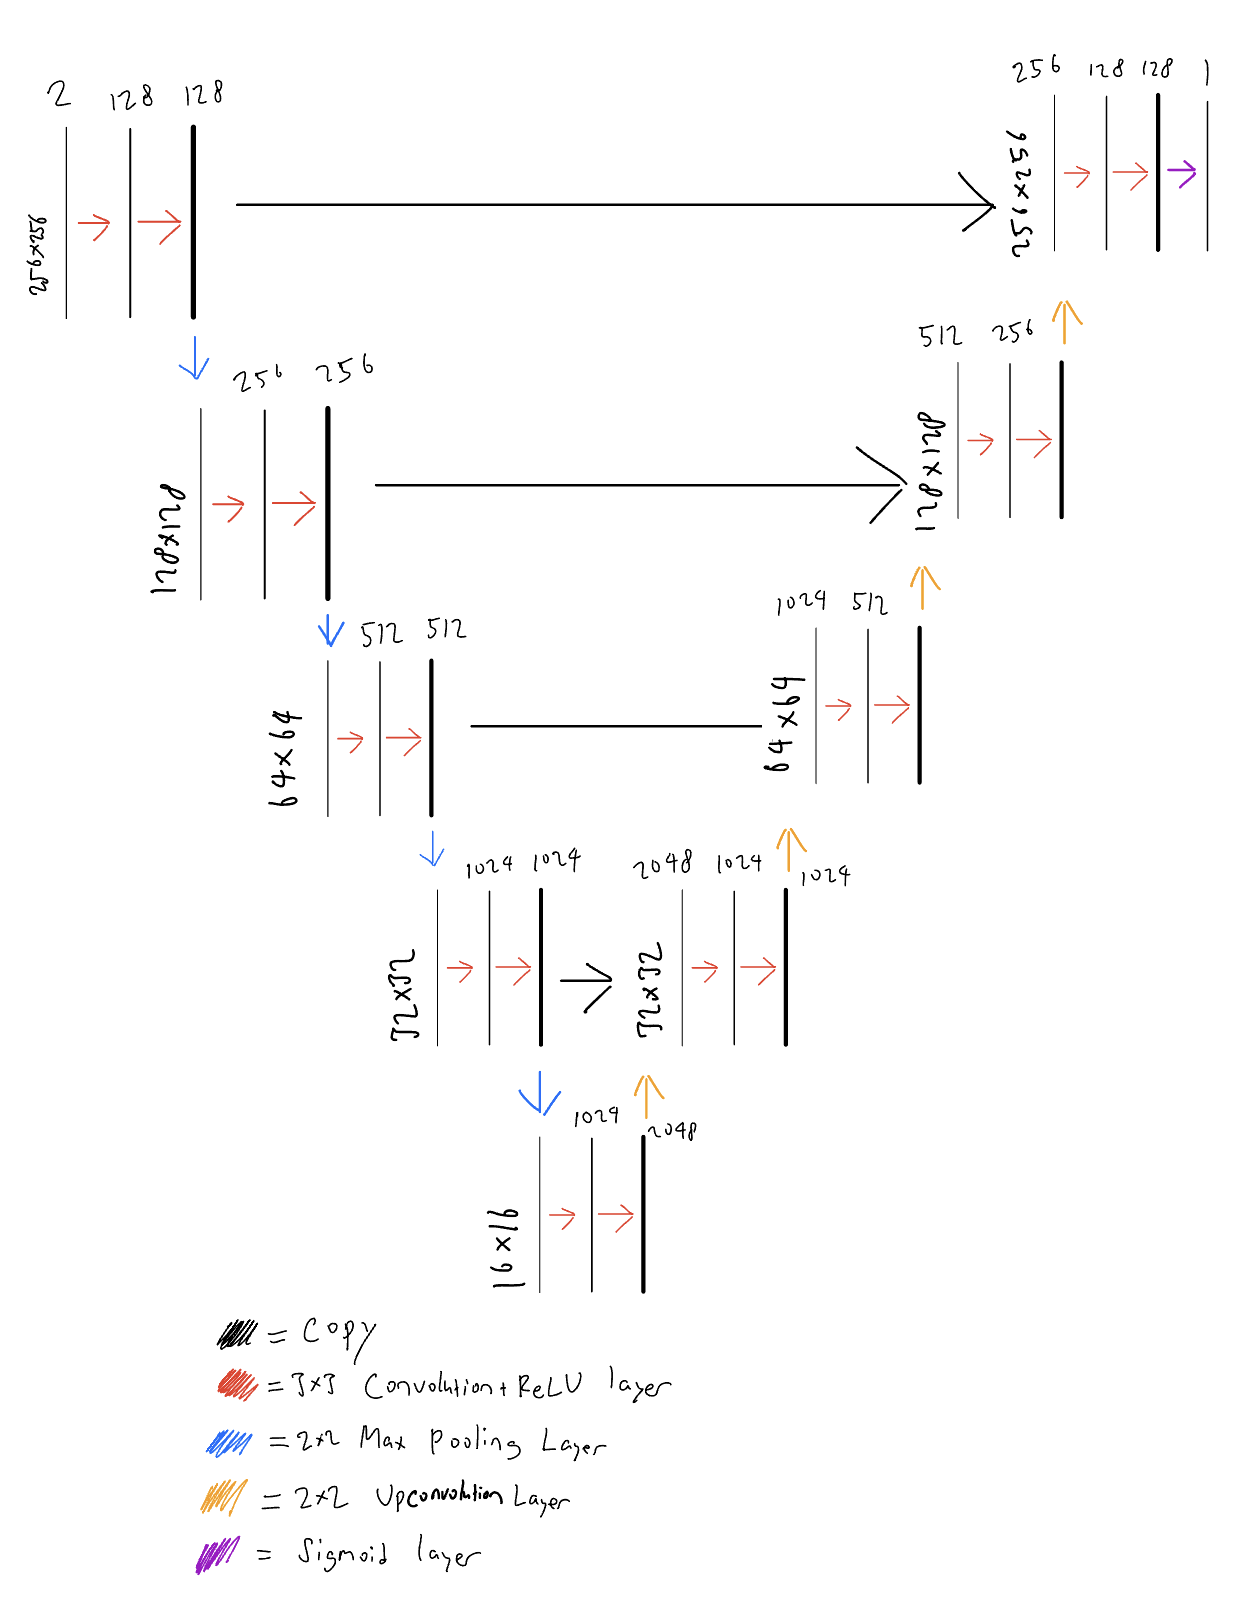

___
### (1.2 -- 1%) List *all* non-trivial features of your CNN and the training process. This may include use of dropout, learning rate scheduling, transfer learning, data augmentation, etc. Don't include items that are visible in the layout provided above.

Answer: The dropout rate was 0.5, padding = 1 for convolutional layers and 0 for maxpool layers. Data augmentation was applied to the training images. "ReduceLROnPlateau" learning rate scheduler was used. torch.cat was used for skip connection on the second half of the Unet, and Stride=2 was used for convolutional layers.

___
### (2.1 -- 0.5%) Provide at least ten hyperparameters that you *could* optimize in your CNN design and training.

Answer: Number of kernels, kernel size, stride, padding size, number of convolutional layers, learning rate, batch size, dropout, initial weights, momentum, choice of activation function, choice of loss function

___
### (2.2 -- 0.5%) Now, list the hyperparameters that you *have* optimized.

Answer: Dropout, learning rate, number of kernels

___
### (2.3 -- 0.5%) Describe your strategy/approach for optimizing hyperparameters.

Answer: For the hyperparameters that were optimized, I started by manually setting fixed values for some of the parameters like channel number and dropout rate, then used a scheduler to change the learning rate based on score results in the training loop. The approach prioritized learning rate over other hyperparameters because optimizing it is important for such a large CNN. Also, some hyperparameters depend on learning rate too, which is why I did not try to optimize all target hyperparamters at once. Once learning rate was in a good spot, it was much easier to progress with the other hyperparameters too.

___
### (2.4 -- 0.5%) What loss function did you use? Express the loss function mathematically.

Answer: MSE loss. MSE = 1/n * summation from i=1 to n of (yi-ypredi)^2

___
### (2.5 -- 1%) Calculate the number of learnable parameters in your final CNN. How does that number compare with the number of training samples? Is your network overfitting or underfitting and how did you arrive at that conclusion? Explain that in the context of loss vs. epoch and/or performance metric vs. epoch curve for training and validation fold.

Answer: Layer 1: (3 x 3 x 2 x 128) + (3 x 3 x 128 x 128) = 149760

Layer 2: (3 x 3 x 128 x 256) + (3 x 3 x 256 x 256) = 884736

Layer 3: (3 x 3 x 256 x 512) + (3 x 3 x 512 x 512) = 3538944

Layer 4: (3 x 3 x 512 x 1024) + (3 x 3 x 1024 x 1024) = 14155776

Layer 5: (3 x 3 x 1024 x 1024) + (3 x 3 x 1024 x 2048) = 28311552

Decoder: 

Upconvolution 1: (2 x 2 x 2048 x 2048) = 16777216

Layer 4: (3 x 3 x 2048 x 1024) + (3 x 3 x 1024 x 1024) = 28311552 

Upconvolution 2: (2 x 2 x 1024 x 1024) = 4194304

Layer 3: (3 x 3 x 1024 x 512) + (3 x 3 x 512 x 512) = 7077888 

Upconvolution 3: (2 x 2 x 512 x 512) = 1048576

Layer 2: (3 x 3 x 512 x 256) + (3 x 3 x 256 x 256) = 1769472 

Upconvolution 4: (2 x 2 x 256 x 256) = 262144 

Layer 1: (3 x 3 x 256 x 128) + (3 x 3 x 128 x 128)+(1 x 1 x 128 x 1) = 442496 

TOTAL LEARNABLE PARAMETERS: 106924416 

The number of learnable parameters far exceeds the number of training samples (1000 in the augemented data set). I don't think the CNN is overfitting or underfitting the data; I think it is generalizing quite well since after 170 epochs the training and validation loss are very close to 0 and the validation loss stabilizes instead of increases, which you would expect to see in overfitting.


___
### (3.1 -- 5%) Insert (or draw using Markdown) a table that provides average values of PSNR, SSIM, and PSNR + 50×SSIM for (i) the trivial inpainting baseline (replace missing pixels with zeros), (ii) images inpainted with the single-layer CNN from `demo_inpainting.ipynb`, and (iii) images inpainted with your CNN. Include metrics from training, validation, and test folds. Note that for the test fold you cannot compute PSNR and SSIM separately as you don't have access to the ground truth. For this fold, report metrics from Kaggle.

___
### (3.2 -- 1%) When it comes to comparing images, what does SSIM capture that PSNR does not?

Answer: SSIM takes the structure of an image into account. Instead of focusing on noise, SSIM focuses on clusters of pixels and how they relate to each other in terms of contrast and shapes that it recognizes.

___
### (4.1 -- 4%) Display a figure where the first row (from left to right) shows (i) an input image without masking, (ii) the masked input image, (iii) the image inpainted with the single-layer CNN from `demo_inpainting.ipynb`, and (iv) the image inpainted with your CNN, and the second row shows the corresponding error maps after 3-fold amplification. For this figure, you may select any image from the validation dataset.

___
### (4.2 -- 1%) From (4.1), subjectively identify which image features are well-recovered by your CNN (e.g., smooth regions, edges, fine structures) and which are not. Additionally, describe how you could further improve the performance of your model if given more time and resources.

Answer: The fine features such as the folds of the brain and all of the darkest spots in the images are well-recovered. The edges are well defined too. Honestly, the input and the recovered images look quite similar. The main difference I see is that the fine medium grey layer of connective tissue along the bottom of the brain in the top image is not well recovered due to the complex cobweb-like structure. I have attached a screenshot below. 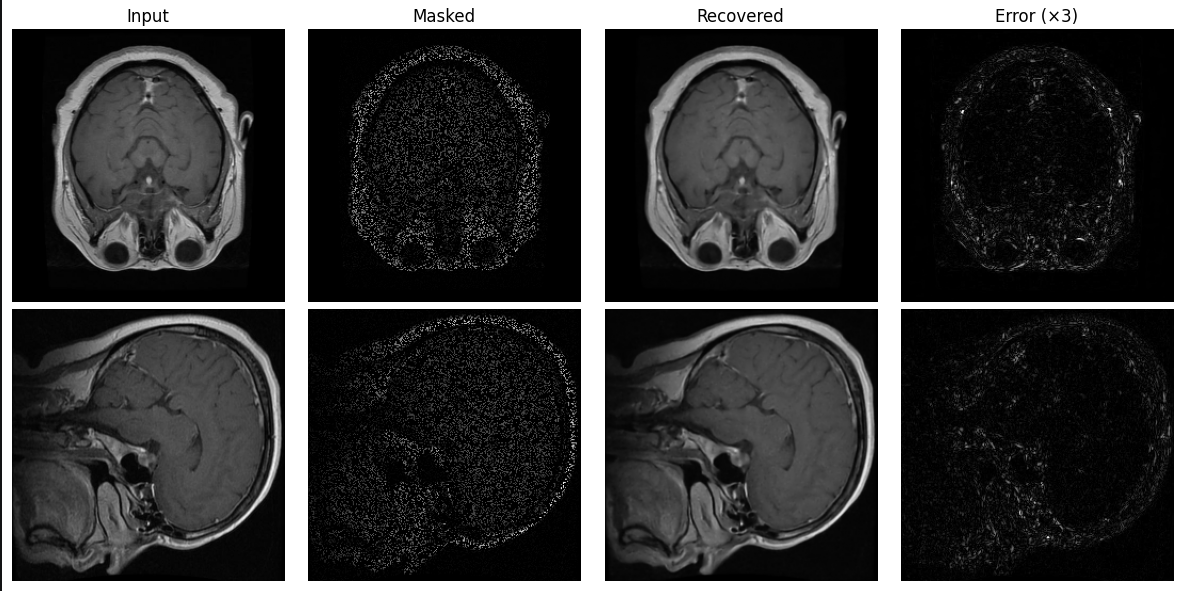

A few improvements I would make to my model with more time and resources is a custom loss function with backpropagation instead of MSE loss and using strided convolutions instead of max pooling. Max pooling only picks the highest number out of that set of numbers in the layer, which can be unreliable and fall short when trying to inpaint super detailed features like the cobweb-like connective tissue I mentioned before. 

___
### (4.3 -- 0%) Describe the extent to which you used AI to complete this project. There is no penalty for using or not using AI. This information helps the instructor understand how AI tools were used in the learning process.

Answer: Google Gemini was used for finetuning and improving the training loop and implementing extra layers. Google Gemini was also used for consulting on how hyperparameters should be changed in order to optimize score.